In [17]:
# Train volterra forward model

inverse_memory_levels = 10
forward_memory_levels = 10

from sparseDPD import Volterra, DataManager, Dataset

# Train Volterra and NN forward models on simple dataset
simpleDataManager = DataManager(filepath='UCD_datasets/PA_IO.mat', num_training_points=19000, num_validaiton_points=1000, num_test_points=2000)

# Setup a volterra model and a volterra inverse
volterra_forward_model = Volterra(num_nl_orders=5, num_memory_levels=forward_memory_levels, dataset=simpleDataManager.training_dataset)

print(f" Volterra NMSE: {volterra_forward_model.calculate_volterra_nmse(simpleDataManager.test_dataset)} dB")

 Volterra NMSE: -41.29829241366064 dB


In [18]:
# Now train inverse model using PNTDNN_3_layer 
from sparseDPD import PNTDNN_NeuralNetwork

# Using PNTDNN on original simple dataset
PNTDNN_inverse_nn = PNTDNN_NeuralNetwork(num_memory_levels=20, model_type='OneLayerNetwork', forward_model=False)
train_losses_inv, valid_losses_inv, best_epoch_inv = PNTDNN_inverse_nn.get_best_model(num_epochs=600, training_dataset=simpleDataManager.training_dataset, 
                                                                               validation_dataset=simpleDataManager.validation_dataset, learning_rate=1e-3)

Using cuda device
Epoch  10/600  Loss=4.7397e+00  Valid Loss=1.4810e-01  LR=1.00e-03
Epoch  20/600  Loss=1.2791e+00  Valid Loss=5.7280e-02  LR=1.00e-03
Epoch  30/600  Loss=7.8945e-01  Valid Loss=3.8566e-02  LR=1.00e-03
Epoch  40/600  Loss=6.1945e-01  Valid Loss=3.4542e-02  LR=1.00e-03
Epoch  50/600  Loss=5.1884e-01  Valid Loss=3.2628e-02  LR=1.00e-03
Epoch  60/600  Loss=4.5064e-01  Valid Loss=2.9916e-02  LR=1.00e-03
Epoch  70/600  Loss=4.2542e-01  Valid Loss=2.8218e-02  LR=1.00e-03
Epoch  80/600  Loss=3.8981e-01  Valid Loss=2.3558e-02  LR=1.00e-03
Epoch  90/600  Loss=3.4564e-01  Valid Loss=1.8211e-02  LR=1.00e-03
Epoch 100/600  Loss=3.1132e-01  Valid Loss=1.6030e-02  LR=1.00e-03
Epoch 110/600  Loss=3.5526e-01  Valid Loss=1.6951e-02  LR=1.00e-03
Epoch 120/600  Loss=2.5817e-01  Valid Loss=1.5009e-02  LR=1.00e-03
Epoch 130/600  Loss=2.4969e-01  Valid Loss=1.5039e-02  LR=1.00e-03
Epoch 140/600  Loss=2.3897e-01  Valid Loss=1.5192e-02  LR=1.00e-03
Epoch 150/600  Loss=2.3361e-01  Valid Loss=1

In [19]:
# # Create full datapath with volterra forward and PNTDNN inverse
# from sparseDPD import Datapath
# datapath = Datapath(forward_model=volterra_forward_model, inverse_model=PNTDNN_inverse_nn)

# data = datapath.process(input_signal=simpleDataManager.test_dataset.input_data)
# datapath.plot_signals(data)

Your inverse model is type <class 'sparseDPD.Volterra.Volterra'> and your forward model is type <class 'sparseDPD.Volterra.Volterra'>


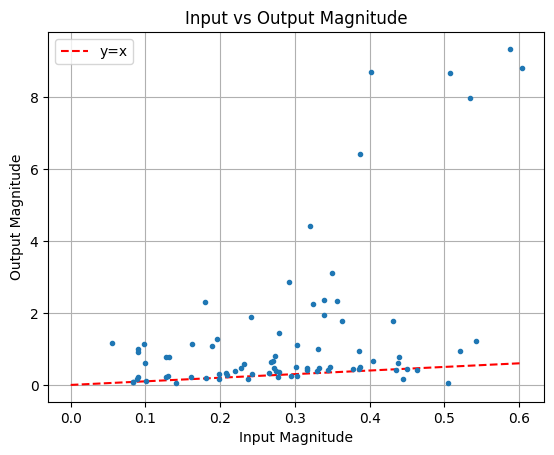

In [20]:
# test does it work with volterra inverse also
from sparseDPD import Datapath
volterra_inverse_model = Volterra(num_nl_orders=5, num_memory_levels=inverse_memory_levels, dataset=simpleDataManager.training_dataset, forward=False)
datapath = Datapath(forward_model=volterra_forward_model, inverse_model=volterra_inverse_model)

data = datapath.process(input_signal=simpleDataManager.test_dataset.input_data[:100])
datapath.plot_signals(data)

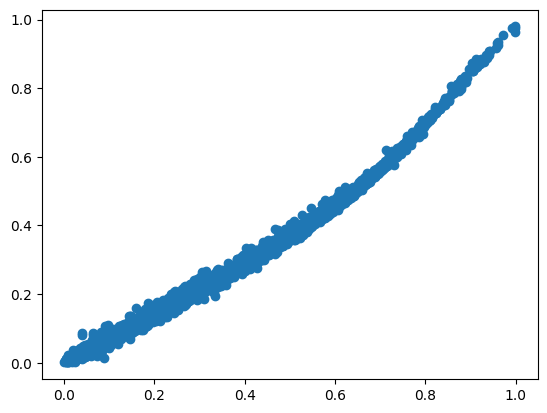

In [21]:
# Plot the output of the invsere volterra model to see if it looks reasonable
import matplotlib.pyplot as plt
import numpy as np

inverse_model_output = volterra_inverse_model.build_y(simpleDataManager.test_dataset.input_data)

# plot input magnitude vs output magnitude for inverse model
plt.plot(np.abs(simpleDataManager.test_dataset.input_data[inverse_memory_levels:]), np.abs(inverse_model_output), 'o')

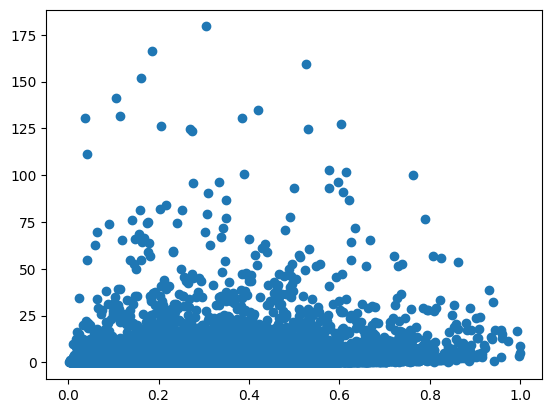

In [22]:
# feed through forward model
forward_model_output = volterra_forward_model.build_y(inverse_model_output)

# Plot
plt.plot(np.abs(simpleDataManager.test_dataset.input_data[inverse_memory_levels + forward_memory_levels:]), np.abs(forward_model_output), 'o')

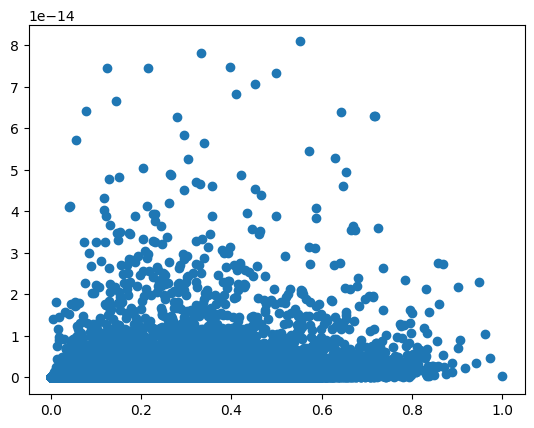

In [23]:
# Now retrain the inverse model based on the current output of the inverse and the output of the PA

iterations = 1

for iteration in range(iterations):
    # Retrain inverse model
    new_dataset = Dataset(input_data = inverse_model_output[inverse_memory_levels:], output_data = forward_model_output)
    volterra_inverse_model.retrain(new_dataset)

    # now get new output from inverse model and forward model and store them
    inverse_model_output = volterra_inverse_model.build_y(simpleDataManager.training_dataset.input_data)
    forward_model_output = volterra_forward_model.build_y(inverse_model_output)

# Plot
plt.plot(np.abs(simpleDataManager.training_dataset.input_data[inverse_memory_levels + forward_memory_levels:]), np.abs(forward_model_output), 'o')



In [24]:
# Try using PNTDNN as the forward model instead 

from sparseDPD.PNTDNN import PNTDNN_NeuralNetwork


PNTDNN_forward_nn = PNTDNN_NeuralNetwork(num_memory_levels=forward_memory_levels, model_type='OneLayerNetwork', forward_model=True)
train_losses_fwd, valid_losses_fwd, best_epoch_fwd = PNTDNN_forward_nn.get_best_model(num_epochs=600, training_dataset=simpleDataManager.training_dataset, validation_dataset=simpleDataManager.validation_dataset)

# Create full datapath with PNTDNN forward and PNTDNN inverse
datapath = Datapath(forward_model=PNTDNN_forward_nn, inverse_model=PNTDNN_inverse_nn)

Using cuda device
Epoch  10/600  Loss=4.2348e+00  Valid Loss=1.9375e-01  LR=1.00e-03  NMSE=-26.6320 dB
Epoch  20/600  Loss=1.8197e+00  Valid Loss=8.9362e-02  LR=1.00e-03  NMSE=-29.9929 dB
Epoch  30/600  Loss=1.1556e+00  Valid Loss=5.6301e-02  LR=1.00e-03  NMSE=-31.9993 dB
Epoch  40/600  Loss=7.7865e-01  Valid Loss=3.9520e-02  LR=1.00e-03  NMSE=-33.5362 dB
Epoch  50/600  Loss=5.7423e-01  Valid Loss=2.8604e-02  LR=1.00e-03  NMSE=-34.9401 dB
Epoch  60/600  Loss=4.7709e-01  Valid Loss=2.4264e-02  LR=1.00e-03  NMSE=-35.6548 dB
Epoch  70/600  Loss=4.0242e-01  Valid Loss=2.1973e-02  LR=1.00e-03  NMSE=-36.0856 dB
Epoch  80/600  Loss=3.6519e-01  Valid Loss=2.0392e-02  LR=1.00e-03  NMSE=-36.4098 dB
Epoch  90/600  Loss=3.3908e-01  Valid Loss=1.8489e-02  LR=1.00e-03  NMSE=-36.8354 dB
Epoch 100/600  Loss=3.2640e-01  Valid Loss=1.7642e-02  LR=1.00e-03  NMSE=-37.0389 dB
Epoch 110/600  Loss=3.1695e-01  Valid Loss=1.7026e-02  LR=1.00e-03  NMSE=-37.1934 dB
Epoch 120/600  Loss=3.0979e-01  Valid Loss=1.66

Your inverse model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'> and your forward model is type <class 'sparseDPD.PNTDNN.PNTDNN_NeuralNetwork'>


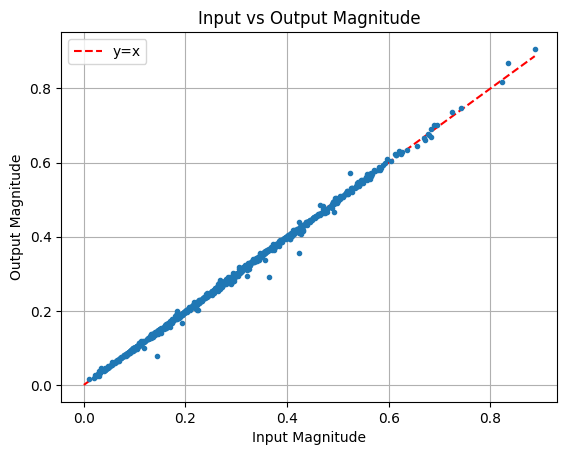

np.float64(-32.96889092275089)

In [25]:
# now plot datapath

data = datapath.process(input_signal=simpleDataManager.test_dataset.input_data[:1000])
datapath.plot_signals(data)
data.calculate_nmse()